In [8]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns


1. The goal is to find the stories that already exist in aft dataset. First we find the the titles with eact match then we embedd all tale titles and find if a story in yashpeh dataset has a match in aft dataset we remove it from yashpeh dataset.

In [3]:
df = pd.read_csv('yashpeh_folktales_with_book_tradition.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4236 entries, 0 to 4235
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      4236 non-null   object
 1   book_name  4235 non-null   object
 2   tradition  4235 non-null   object
 3   url        4236 non-null   object
 4   story_id   4236 non-null   int64 
 5   text       4236 non-null   object
dtypes: int64(1), object(5)
memory usage: 198.7+ KB


In [4]:
df_aft = pd.read_csv('aft.csv')
df_aft.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   atu_id         1518 non-null   object
 1   tale_title     1518 non-null   object
 2   provenance     1502 non-null   object
 3   notes          831 non-null    object
 4   source         1336 non-null   object
 5   text           1518 non-null   object
 6   data_source    1518 non-null   object
 7   date_obtained  1518 non-null   object
dtypes: object(8)
memory usage: 95.0+ KB


In [ ]:
#remove stories with exact title match
df_clean = df['title'].astype(str).str.strip().str.lower()
df2_clean = df_aft['tale_title'].astype(str).str.strip().str.lower()

df = df[~df_clean.isin(df2_clean)].copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4009 entries, 0 to 4235
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      4009 non-null   object
 1   book_name  4008 non-null   object
 2   tradition  4008 non-null   object
 3   url        4009 non-null   object
 4   story_id   4009 non-null   int64 
 5   text       4009 non-null   object
dtypes: int64(1), object(5)
memory usage: 219.2+ KB


In [6]:
#remove stories with very similar titles

model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda" if torch.cuda.is_available() else "cpu")

titles_df   = df['title'].astype(str).str.strip().tolist()
titles_aft  = df_aft['tale_title'].astype(str).str.strip().tolist()

emb_df  = model.encode(titles_df,  batch_size=64, show_progress_bar=True, convert_to_tensor=True)
emb_aft = model.encode(titles_aft, batch_size=64, show_progress_bar=True, convert_to_tensor=True)

similarities = util.semantic_search(emb_df, emb_aft, top_k=1, score_function=util.cos_sim)
max_sim = np.array([hit[0]['score'] for hit in similarities])   # force numpy

THRESHOLD = 0.8

mask = max_sim < THRESHOLD


mask = pd.Series(mask, index=df.index)

df_unique = df[mask].copy()

print(f"Kept {mask.sum():,} / {len(df):,} rows (max similarity < {THRESHOLD})")

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Kept 3,814 / 4,009 rows (max similarity < 0.8)


2. Length Analysis: Some folktales in Yashpeh dataset aren't complete (This is not due to a problem in scrapping). We remove stories whose length is less than 500 and then store the stories based on the increasign length.

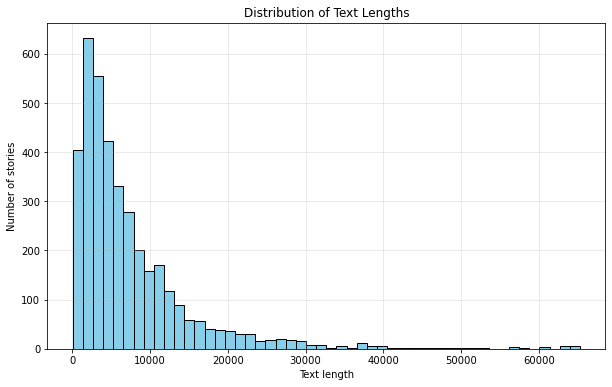

In [10]:



df_unique['text_length'] = df_unique['text'].astype(str).str.len()

plt.figure(figsize=(10, 6))
plt.hist(df_unique['text_length'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Text Lengths')
plt.xlabel('Text length')
plt.ylabel('Number of stories')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df_unique = df_unique.rename(columns={'title': 'tale_title'})

In [ ]:
min_length = 500

df_unique = df_unique[
    df_unique['text'].str.len() >= min_length
].reset_index(drop=True)

In [ ]:

df_unique = df_unique.sort_values(
    by='text',
    key=lambda x: x.str.len(),         
    ascending=True
).reset_index(drop=True)                 


In [ ]:
df_unique.to_csv('yashpeh_folktales_cleaned.csv')